# Voyager X Signal Classifier

Classify signals as **Background Cosmic Noise (Class 0)** or **Potential Alien Beacons (Class 1)** using single-layer networks.

## Dataset Generation

Generate synthetic data with two features: **Intensity** and **Frequency Stability**.

- **Class 1 (Beacons):** 500 samples, $\mu_1 = [2, 2]^T$, $\Sigma_1 = \begin{bmatrix} 0.5 & 0.2 \\ 0.2 & 0.5 \end{bmatrix}$
- **Class 0 (Noise):** 500 samples, $\mu_0 = [-2, -2]^T$, $\Sigma_0 = \begin{bmatrix} 1.0 & -0.3 \\ -0.3 & 1.0 \end{bmatrix}$
- **Outliers:** Add 10 points to Class 0 at $\mu = [6, 6]^T$, $\Sigma = 0.1 \cdot I$

In [15]:
# TODO
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import train_test_split

np.random.seed(42)


N1 = 500  # Beacons
N0 = 500  # Noise
mu1 = np.array([2.0, 2.0])
Sigma1 = np.array([[0.5, 0.2],[0.2, 0.5]])
mu0 = np.array([-2.0, -2.0])
Sigma0 = np.array([[1.0, -0.3],[-0.3, 1.0]])

X1 = np.random.multivariate_normal(mu1, Sigma1, size=N1)
X0 = np.random.multivariate_normal(mu0, Sigma0, size=N0)

# Add outliers to class 0
outliers = np.random.multivariate_normal(np.array([6.0,6.0]), 0.1*np.eye(2), size=10)
X0[:10] = outliers  # replace first 10 of noise with outliers

X = np.vstack([X0, X1])
y = np.hstack([np.zeros(N0), np.ones(N1)])

# Train/test split to evaluate generalization
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=1)

print("Dataset sizes: Train:", X_train.shape, "Test:", X_test.shape)
print(X0.shape, X1.shape,X.shape,y.shape)

# Add bias feature for closed form linear solutions: phi = [1, x1, x2]
def add_bias(X):
    return np.hstack([np.ones((X.shape[0],1)), X])

Phi_train = add_bias(X_train)
Phi_test = add_bias(X_test)
print("Phi_train shape:", Phi_train.shape, "Phi_test shape:", Phi_test.shape)

Dataset sizes: Train: (700, 2) Test: (300, 2)
(500, 2) (500, 2) (1000, 2) (1000,)
Phi_train shape: (700, 3) Phi_test shape: (300, 3)


## Part 1: Least Squares Classification

Use binary encoding: $t=1$ for Beacons, $t=0$ for Noise.

Implement the closed-form solution:
$$\mathbf{W} = (\mathbf{\Phi}^T \mathbf{\Phi})^{-1} \mathbf{\Phi}^T \mathbf{T}$$

Predict: $y(\mathbf{x}) = \mathbf{W}^T \mathbf{\phi}(\mathbf{x})$. Assign Class 1 if $y \geq 0.5$.

In [16]:
# TODO: Implement Least Squares classifier
T_train = y_train.reshape(-1,1)  # targets 0/1 in column vector
W = np.linalg.pinv(Phi_train.T @ Phi_train) @ (Phi_train.T @ T_train)  # shape (3,1)
W = W.flatten()

def ls_predict_proba(X):
    # y = W^T phi
    phi = add_bias(X)
    linear = phi @ W
    prob = 1.0/(1.0 + np.exp(-linear))
    return prob, linear

ls_prob_test, ls_linear_test = ls_predict_proba(X_test)
ls_pred_test = (ls_linear_test >= 0.5).astype(int)

print("\nLeast Squares parameters W:", W)


Least Squares parameters W: [0.48175501 0.11056093 0.1041993 ]


## Part 2: Generative Models (Gaussian Discriminant Analysis)

Estimate class-conditional densities $p(\mathbf{x}|C_k)$ and use Bayes' theorem.

**Case A:** Shared covariance $\Sigma$ (pooled) → Linear boundary  
**Case B:** Separate covariances $\Sigma_0, \Sigma_1$ → Quadratic boundary

Posterior: $p(C_1|\mathbf{x}) = \sigma(\mathbf{w}^T\mathbf{x} + w_0)$

In [17]:
# TODO: Implement Quadratic Discriminant Analysis
# Estimate class-wise means and covariances from training data
mu0_hat = X_train[y_train==0].mean(axis=0)
mu1_hat = X_train[y_train==1].mean(axis=0)
Sigma0_hat = np.cov(X_train[y_train==0].T)
Sigma1_hat = np.cov(X_train[y_train==1].T)
N0_hat = (y_train==0).sum()
N1_hat = (y_train==1).sum()
pi0 = N0_hat / (N0_hat + N1_hat)
pi1 = N1_hat / (N0_hat + N1_hat)
print(mu0_hat, mu1_hat, Sigma0_hat, Sigma1_hat ,N0_hat, N1_hat, pi0, pi1)

# Case A: shared covariance (pooled)
Sigma_pooled = ( (N0_hat-1)*Sigma0_hat + (N1_hat-1)*Sigma1_hat ) / (N0_hat + N1_hat - 2)
Sigma_pinv = np.linalg.inv(Sigma_pooled)
print("Pooled Covariance:\n", Sigma_pooled, "\nInverse:\n", Sigma_pinv)

w_lda = Sigma_pinv @ (mu1_hat - mu0_hat)            # 2-d vector
w0_lda = -0.5 * mu1_hat.T @ Sigma_pinv @ mu1_hat + 0.5 * mu0_hat.T @ Sigma_pinv @ mu0_hat + np.log(pi1/pi0)
print("LDA parameters w:", w_lda, "w0:", w0_lda)

def lda_decision_function(X):
    # linear score s(x) = w^T x + w0
    return X @ w_lda + w0_lda

def lda_proba(X):
    # pass linear score through sigmoid for a posterior estimate
    s = lda_decision_function(X)
    return 1.0/(1.0 + np.exp(-s))

lda_prob_test = lda_proba(X_test)
lda_pred_test = (lda_prob_test >= 0.5).astype(int)

# Case B: Quadratic Discriminant Analysis
rv0 = multivariate_normal(mean=mu0_hat, cov=Sigma0_hat, allow_singular=False)
rv1 = multivariate_normal(mean=mu1_hat, cov=Sigma1_hat, allow_singular=False)

def qda_log_posterior_ratio(X):
    # log p1 - log p0 + log(pi1/pi0)
    logp1 = rv1.logpdf(X) + np.log(pi1)
    logp0 = rv0.logpdf(X) + np.log(pi0)
    return logp1 - logp0

qda_score_test = qda_log_posterior_ratio(X_test)
qda_prob_test = 1.0/(1.0 + np.exp(-qda_score_test))
qda_pred_test = (qda_prob_test >= 0.5).astype(int)


[-1.85885457 -1.70226277] [1.93163808 1.97522977] [[1.94535331 0.85221193]
 [0.85221193 1.90266909]] [[0.47683018 0.18442805]
 [0.18442805 0.49658426]] 350 350 0.5 0.5
Pooled Covariance:
 [[1.21109175 0.51831999]
 [0.51831999 1.19962668]] 
Inverse:
 [[ 1.01302507 -0.43769545]
 [-0.43769545  1.02270675]]
LDA parameters w: [2.23024232 2.10191504] w0: -0.36803915492025974


## Part 3: Logistic Regression (Discriminative Model)

Model the posterior directly: $p(C_1|\mathbf{x}) = \sigma(\mathbf{w}^T\mathbf{\phi})$

Cross-Entropy Loss:
$$E(\mathbf{w}) = -\sum_{n=1}^{N} \left[ t_n \ln y_n + (1-t_n) \ln(1-y_n) \right]$$

Gradient:
$$\nabla E(\mathbf{w}) = \sum_{n=1}^{N} (y_n - t_n)\mathbf{\phi}_n$$

In [18]:
# TODO: Train a Logistic Regression Model
# NOTE: You don't need to write it from scratch. You can use existing libraries like scikit-learn for this part
# Refer to d2l.ai or the numerous other online tutorials for help
clf = LogisticRegression(solver='lbfgs', max_iter=200)
clf.fit(X_train, y_train)
logreg_prob_test = clf.predict_proba(X_test)[:,1]
logreg_pred_test = (logreg_prob_test >= 0.5).astype(int)
print("\nLogistic Regression coefficients:", clf.coef_, "intercept:", clf.intercept_)
print(logreg_pred_test)


Logistic Regression coefficients: [[0.9783893  0.99511748]] intercept: [-0.30977513]
[1 0 0 0 1 0 0 1 1 0 1 1 0 1 1 1 0 1 1 1 1 1 0 1 0 0 1 0 0 1 0 1 0 1 0 1 1
 0 0 1 0 0 0 1 1 1 1 1 0 0 1 1 0 1 0 0 1 1 1 0 0 0 1 1 1 0 0 0 1 1 1 0 1 0
 0 1 0 1 1 0 1 0 0 0 1 1 1 1 1 1 0 1 0 1 0 0 1 0 1 0 0 1 0 0 1 0 0 0 1 1 1
 1 1 1 1 1 0 0 0 1 1 0 0 0 1 1 0 0 0 1 0 0 0 0 0 1 0 1 1 1 1 1 1 0 1 1 1 1
 0 1 0 1 0 0 0 0 0 1 1 0 1 0 0 1 0 0 0 1 0 1 1 0 1 0 0 0 1 1 0 1 0 0 0 1 0
 1 0 1 1 1 0 1 1 1 0 1 0 0 0 1 0 1 0 0 0 0 1 0 0 1 1 1 1 1 0 0 1 0 0 0 0 1
 0 1 0 1 1 1 1 0 1 1 1 0 0 0 1 1 1 1 1 0 0 1 1 0 1 0 1 1 1 0 0 0 1 0 0 0 1
 1 0 1 1 1 0 1 0 0 1 1 0 1 0 0 0 1 0 0 1 0 1 1 1 0 0 0 0 1 0 0 0 0 1 1 1 1
 1 1 0 1]


## Part 4: Decision Theory

**Loss Matrix:**
- Classifying Beacon as Noise (FN): Loss = 100
- Classifying Noise as Beacon (FP): Loss = 1

Optimal decision minimizes expected loss:
$$\mathbb{E}[L] = \sum_k L_{kj} p(C_k|\mathbf{x})$$


Asymmetric loss decision threshold for p(C1|x): 0.009900990099009901

LeastSquares Accuracy: 0.9867
              precision    recall  f1-score   support

         0.0     1.0000    0.9733    0.9865       150
         1.0     0.9740    1.0000    0.9868       150

    accuracy                         0.9867       300
   macro avg     0.9870    0.9867    0.9867       300
weighted avg     0.9870    0.9867    0.9867       300


LDA Accuracy: 0.9867
              precision    recall  f1-score   support

         0.0     1.0000    0.9733    0.9865       150
         1.0     0.9740    1.0000    0.9868       150

    accuracy                         0.9867       300
   macro avg     0.9870    0.9867    0.9867       300
weighted avg     0.9870    0.9867    0.9867       300


QDA Accuracy: 0.9967
              precision    recall  f1-score   support

         0.0     1.0000    0.9933    0.9967       150
         1.0     0.9934    1.0000    0.9967       150

    accuracy                         

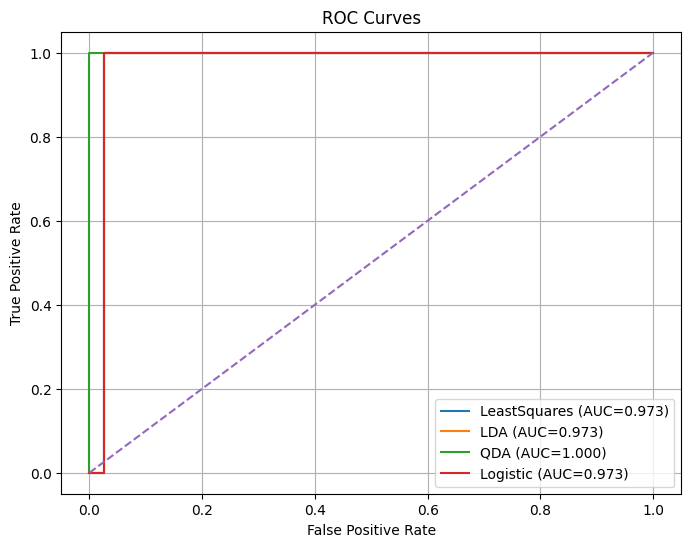

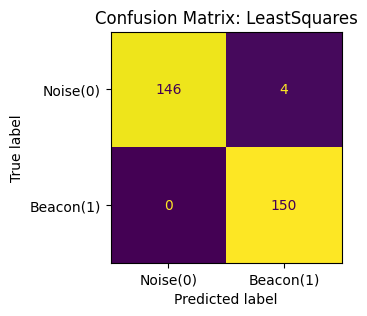

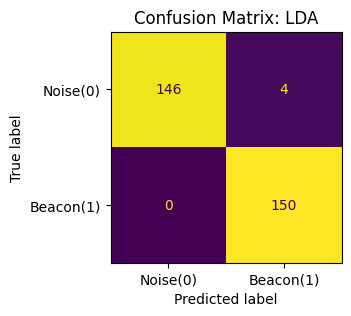

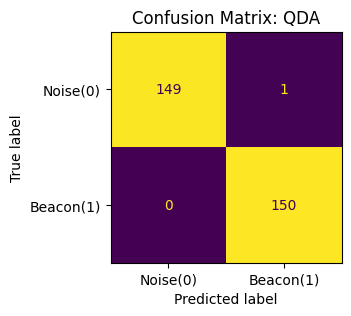

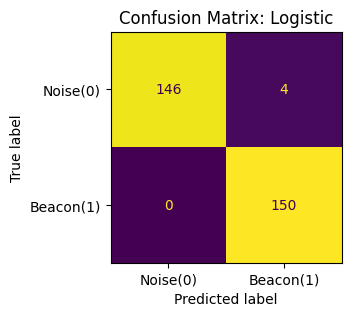

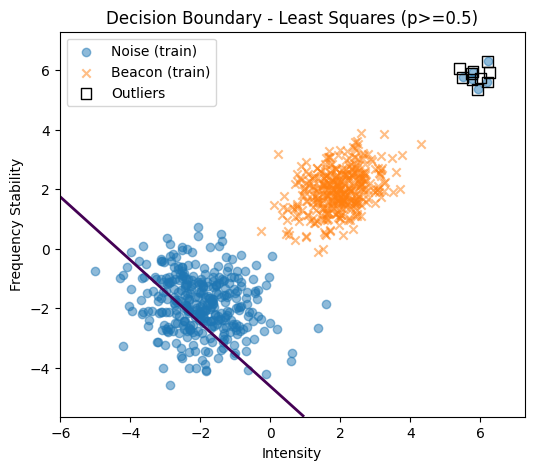

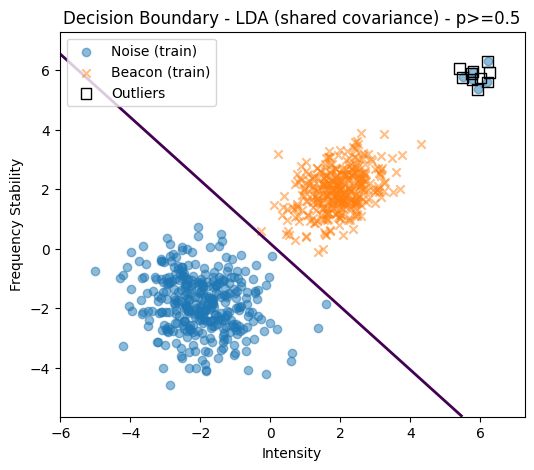

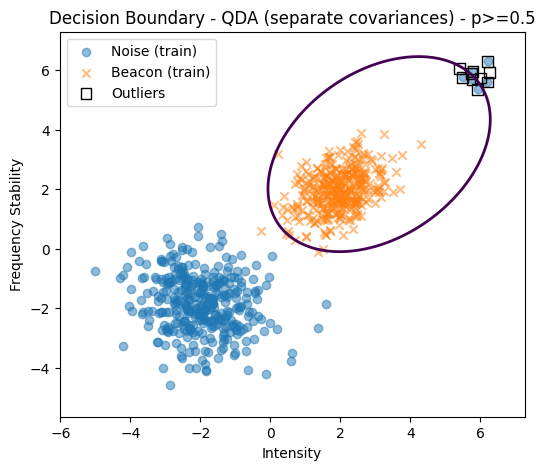

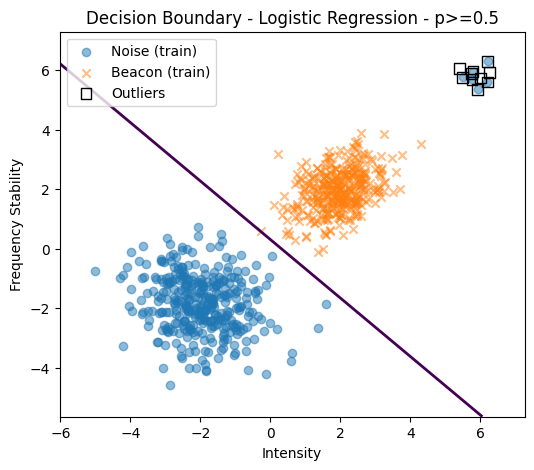

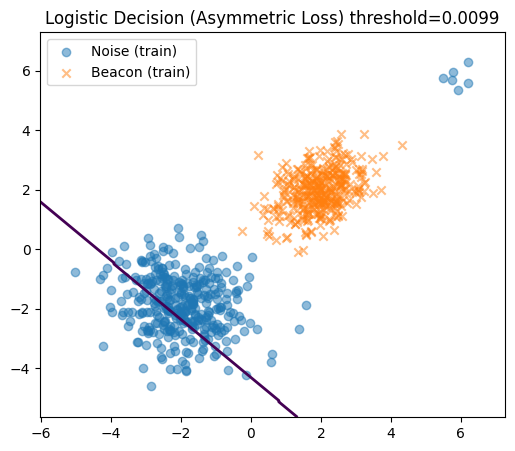

In [19]:
# TODO: Plot the following for all 3 classifiers --
# 1. ROC curve
# 2. Confusion Matrix
# 3. Decision boundaries and datapoints
# NOTE: You can use external libraries such as scikit-learn for this part


asym_threshold = 1.0/101.0
print("\nAsymmetric loss decision threshold for p(C1|x):", asym_threshold)

# Apply threshold to logistic regression posterior (best calibrated)
logreg_pred_asym = (logreg_prob_test >= asym_threshold).astype(int)

models = {
    'LeastSquares': (ls_prob_test, ls_pred_test),
    'LDA': (lda_prob_test, lda_pred_test),
    'QDA': (qda_prob_test, qda_pred_test),
    'Logistic': (logreg_prob_test, logreg_pred_test)
}

# Print test performance metrics
for name, (probs, preds) in models.items():
    acc = accuracy_score(y_test, preds)
    print(f"\n{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, preds, digits=4))

# Logistic with asymmetric decision
print("\nLogistic (asymmetric loss) accuracy:", accuracy_score(y_test, logreg_pred_asym))
print(confusion_matrix(y_test, logreg_pred_asym))

# ROC curves and AUCs
plt.figure(figsize=(8,6))
for name, (probs, preds) in models.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")
plt.plot([0,1],[0,1], linestyle='--')
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

for name, (probs, preds) in models.items():
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Noise(0)','Beacon(1)'])
    fig, ax = plt.subplots(figsize=(4,3))
    disp.plot(ax=ax, cmap=None, colorbar=False)
    ax.set_title(f"Confusion Matrix: {name}")
    plt.show()

# Prepare grid
xx = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 300)
yy = np.linspace(X[:,1].min()-1, X[:,1].max()+1, 300)
XX, YY = np.meshgrid(xx, yy)
grid = np.column_stack([XX.ravel(), YY.ravel()])

# LS boundary: linear W (bias included)
phi_grid = add_bias(grid)
ls_scores = phi_grid @ W
ls_probs_grid = 1.0/(1.0 + np.exp(-ls_scores))

# LDA boundary
lda_scores_grid = lda_decision_function(grid)
lda_probs_grid = 1.0/(1.0 + np.exp(-lda_scores_grid))

# QDA boundary via log posterior ratio
qda_scores_grid = qda_log_posterior_ratio(grid)
qda_probs_grid = 1.0/(1.0 + np.exp(-qda_scores_grid))

# Logistic grid
logreg_probs_grid = clf.predict_proba(grid)[:,1]

# Plot function to draw boundary and scatter
def plot_boundary(probs_grid, title):
    Z = probs_grid.reshape(XX.shape)
    plt.figure(figsize=(6,5))
    # Contour for decision boundary at p=0.5
    cs = plt.contour(XX, YY, Z, levels=[0.5], linewidths=2)
    plt.scatter(X_train[y_train==0,0], X_train[y_train==0,1], marker='o', alpha=0.5, label='Noise (train)')
    plt.scatter(X_train[y_train==1,0], X_train[y_train==1,1], marker='x', alpha=0.5, label='Beacon (train)')
    plt.scatter(outliers[:,0], outliers[:,1], marker='s', s=60, edgecolor='k', label='Outliers', facecolors='none')
    plt.title(title)
    plt.xlabel("Intensity")
    plt.ylabel("Frequency Stability")
    plt.legend()
    plt.show()

plot_boundary(ls_probs_grid, "Decision Boundary - Least Squares (p>=0.5)")
plot_boundary(lda_probs_grid, "Decision Boundary - LDA (shared covariance) - p>=0.5")
plot_boundary(qda_probs_grid, "Decision Boundary - QDA (separate covariances) - p>=0.5")
plot_boundary(logreg_probs_grid, "Decision Boundary - Logistic Regression - p>=0.5")

# Also show logistic decision boundary with asymmetric threshold
logreg_probs_grid_asym = logreg_probs_grid >= asym_threshold
plt.figure(figsize=(6,5))
plt.contour(XX, YY, logreg_probs_grid_asym.reshape(XX.shape), levels=[0.5], linewidths=2)
plt.scatter(X_train[y_train==0,0], X_train[y_train==0,1], marker='o', alpha=0.5, label='Noise (train)')
plt.scatter(X_train[y_train==1,0], X_train[y_train==1,1], marker='x', alpha=0.5, label='Beacon (train)')
plt.title(f"Logistic Decision (Asymmetric Loss) threshold={asym_threshold:.4f}")
plt.legend()
plt.show()